# Gradient audit

This notebook contains three gradient checks: analytical versus finite-difference gradients, the sign of $K'_{IRB}$, and the fixed-$\rho$ versus full-gradient approximation.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.special import ndtri
from scipy.stats import norm

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from common.decision import DecisionConfig
from common import decision as dec
from common import dfl_model as dm


# Set up baseline parameters
DCFG = DecisionConfig(LGD=0.45, K1=1.0, ell=10.0, Y_BAR=0.0168, lambda_shortfall=10.0, M=2.5,
    RHO_SCALE=0.03, APPLY_PD_FLOOR=True, PD_FLOOR=3e-4,
    PD_Q_CLIP_LOW=1e-6, PD_Q_CLIP_HIGH=0.99, PD_A_CLIP_LOW=1e-6, PD_A_CLIP_HIGH=0.99,
    ALPHA_BOUNDS=(0.0, 1.0), ALPHA_OPT_XATOL=1e-10)

pd.set_option('display.float_format', lambda x: f'{x:.6g}')

## Gradient Verification

The table below compares the fully analytical IFT gradient with finite differences.


In [3]:
def fd_gradient(pd_q, dcfg, include_rho_channel=True, h_rel=1e-6):
    pd_q = np.atleast_1d(np.asarray(pd_q, dtype=float))
    h = np.maximum(1e-9, h_rel * pd_q)
    a_up, _ = dm.solve_alpha_star(pd_q + h, dcfg, include_rho_channel=include_rho_channel)
    a_dn, _ = dm.solve_alpha_star(pd_q - h, dcfg, include_rho_channel=include_rho_channel)
    return (a_up - a_dn) / (2*h)

pd_cases = np.array([0.001, 0.003, 0.014, 0.0372])
case_names = ['Low PD', 'Median PD', 'High PD', 'Near Boundary']
analytical = dm.solve_alpha_star(pd_cases, DCFG, include_rho_channel=False)[1]
finite_difference = fd_gradient(pd_cases, DCFG, include_rho_channel=False)
gradient_verification = pd.DataFrame({
    'Case': case_names, 'Analytical': analytical, 'Finite-difference': finite_difference,
    'Absolute Error': np.abs(analytical - finite_difference)})
display(gradient_verification)

latex_for_print = gradient_verification.copy()
for column in ['Analytical', 'Finite-difference']:
    latex_for_print[column] = latex_for_print[column].map(lambda x: f'{x:.1f}')
latex_for_print['Absolute Error'] = latex_for_print['Absolute Error'].map(lambda x: f'{x:.1e}')
latex_table = latex_for_print.to_latex(
    index=False,
    escape=False,
    column_format="cccc",
    caption=r"Analytical versus finite-difference verification of $d\alpha^*/dPD$.",
    label="tab:gradient_verification",
)

latex_table = latex_table.replace(
    r"\begin{table}",
    r"\begin{table}[H]" + "\n    \\centering"
)

print(latex_table)

,Case,Analytical,Finite-difference,Absolute Error
0,Low PD,-138.037,-137.822,0.215207
1,Median PD,-35.0823,-34.9211,0.161231
2,High PD,-7.81508,-7.78242,0.0326601
3,Near Boundary,-9.61317,-9.61269,0.00047892


\begin{table}[H]
    \centering
\caption{Analytical versus finite-difference verification of $d\alpha^*/dPD$.}
\label{tab:gradient_verification}
\begin{tabular}{cccc}
\toprule
Case & Analytical & Finite-difference & Absolute Error \\
\midrule
Low PD & -138.0 & -137.8 & 2.2e-01 \\
Median PD & -35.1 & -34.9 & 1.6e-01 \\
High PD & -7.8 & -7.8 & 3.3e-02 \\
Near Boundary & -9.6 & -9.6 & 4.8e-04 \\
\bottomrule
\end{tabular}
\end{table}



## Sign of IRB gradient 

$K'_{IRB}$ is not monotonically increasing in PD over $[0,1]$. The calculation below locates its maximum and checks the relevant simulated and empirical PD ranges.


K_IRB peaks at PD^A=29.6216% (PD^Q=8.4075%).
Lower-allocation boundary y_bar/LGD=3.7333% quarterly PD.
simulated: min K_prime=0.781435; all positive=True
empirical: min K_prime=0.777026; all positive=True


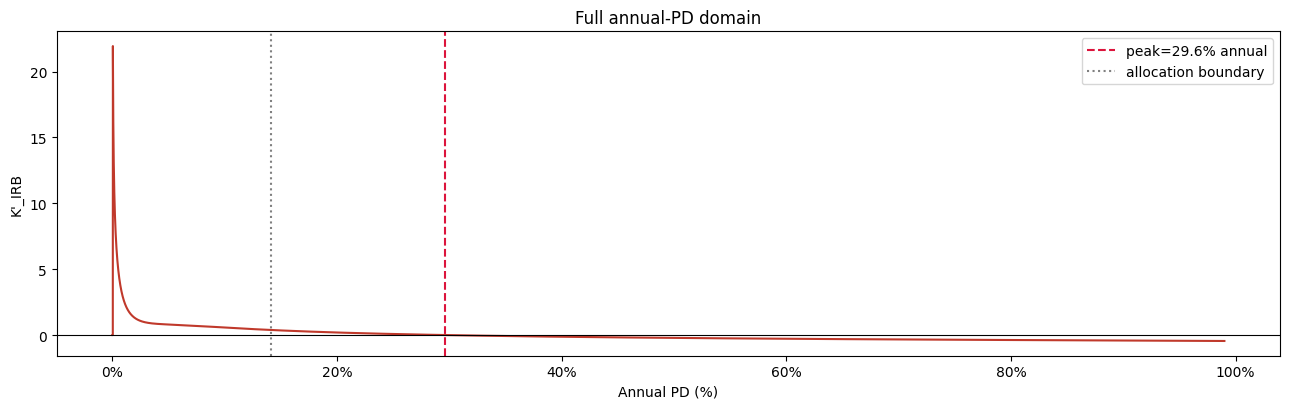

In [4]:
pd_a_grid = np.linspace(1e-6, 0.99, 40000)
k_vals = dec.k_irb_from_annual_pd(pd_a_grid, DCFG)
k_prime = np.gradient(k_vals, pd_a_grid)
peak_idx = int(np.argmax(k_vals))
peak_a = float(pd_a_grid[peak_idx])
peak_q = float(1 - (1 - peak_a)**0.25)
boundary_q = DCFG.Y_BAR / DCFG.LGD
print(f'K_IRB peaks at PD^A={peak_a:.4%} (PD^Q={peak_q:.4%}).')
print(f'Lower-allocation boundary y_bar/LGD={boundary_q:.4%} quarterly PD.')
for lo_q, hi_q, label in [(0.001, 0.014, 'simulated'), (0.0007, 0.0143, 'empirical')]:
    lo_a, hi_a = 1-(1-lo_q)**4, 1-(1-hi_q)**4
    mask = (pd_a_grid >= lo_a) & (pd_a_grid <= hi_a)
    print(f'{label}: min K_prime={k_prime[mask].min():.6g}; all positive={bool((k_prime[mask] > 0).all())}')
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(pd_a_grid, k_prime, color='#c0392b')
ax.axhline(0, color='black', lw=.8)
ax.axvline(peak_a, color='crimson', ls='--', label=f'peak={peak_a:.1%} annual')
ax.axvline(1-(1-boundary_q)**4, color='grey', ls=':', label='allocation boundary')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(xlabel='Annual PD (%)', ylabel="K'_IRB", title='Full annual-PD domain')
ax.legend()
plt.tight_layout()
plt.show()

## Fixed-$\rho$ versus full gradient

This compares $d\alpha^*/dPD$ with the rho channel frozen and with the full dependence of $\rho$ on PD. It reports mean and maximum relative differences and sign disagreements.


In [5]:
def compare_channel(pd_q, dcfg):
    pd_q = np.atleast_1d(np.asarray(pd_q, dtype=float))
    _, frozen = dm.solve_alpha_star(pd_q, dcfg, include_rho_channel=False)
    _, full = dm.solve_alpha_star(pd_q, dcfg, include_rho_channel=True)
    abs_diff = np.abs(full-frozen)
    rel_diff = abs_diff / np.maximum(np.abs(frozen), 1e-8)
    return pd.DataFrame({'relative_difference': rel_diff, 'sign_disagree': (np.sign(frozen)!=np.sign(full)) & (np.abs(frozen)>1e-9)})

sim_path = PROJECT_ROOT / 'data_panels/panel_seed42_lam10_T500_rho0p03.csv'
sim_pd = pd.read_csv(sim_path)['PD_quarterly_true'].to_numpy()

def audit_row(panel_name, pd_values, rho_scale):
    cfg = DecisionConfig(**{**DCFG.__dict__, 'RHO_SCALE': rho_scale})
    out = compare_channel(pd_values, cfg)
    return {'Panel': panel_name, 's_rho': rho_scale, 'Mean relative difference (%)': 100*out.relative_difference.mean(),
            'Maximum relative difference (%)': 100*out.relative_difference.max(), 'Sign disagreements': int(out.sign_disagree.sum())}

rows = []
for rho_scale in [0.03, 0.1, 0.25, 0.5, 1]:
    rows += [audit_row('Simulated', sim_pd, rho_scale)]
rho_gradient_comparison = pd.DataFrame(rows)
display(rho_gradient_comparison)

,Panel,s_rho,Mean relative difference (%),Maximum relative difference (%),Sign disagreements
0,Simulated,0.03,0.397984,0.850926,0
1,Simulated,0.1,0.897053,1.86649,0
2,Simulated,0.25,1.78194,3.60494,0
3,Simulated,0.5,3.10705,6.14277,0
4,Simulated,1,5.51994,10.7395,0


In [6]:
# Lambda sensitivity at fixed s_rho = 0.03.
def audit_lambda_row(panel_name, pd_values, lambda_shortfall):
    cfg = DecisionConfig(**{**DCFG.__dict__, 'RHO_SCALE': 0.03,
                           'lambda_shortfall': lambda_shortfall})
    out = compare_channel(pd_values, cfg)
    return {'Panel': panel_name, 'lambda': lambda_shortfall, 's_rho': 0.03,
            'Mean relative difference (%)': 100*out.relative_difference.mean(),
            'Maximum relative difference (%)': 100*out.relative_difference.max(),
            'Sign disagreements': int(out.sign_disagree.sum())}

lambda_rows = []
for lambda_shortfall in [1, 5, 10, 20, 50, 100]:
    lambda_rows += [audit_lambda_row('Simulated', sim_pd, lambda_shortfall)]
rho_channel_lambda_comparison = pd.DataFrame(lambda_rows)
display(rho_channel_lambda_comparison)

,Panel,lambda,s_rho,Mean relative difference (%),Maximum relative difference (%),Sign disagreements
0,Simulated,1,0.03,0.18427,0.430064,0
1,Simulated,5,0.03,0.335823,0.729574,0
2,Simulated,10,0.03,0.397984,0.850926,0
3,Simulated,20,0.03,0.459084,0.969242,0
4,Simulated,50,0.03,0.538738,1.12207,0
5,Simulated,100,0.03,0.598416,1.23557,0
